# The big-ad signal — do Super Bowl advertisers drift up? 📺
### The company that buys a $7-million commercial, gets the buzz, and pops — in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Big-ad signal?: Not supported](https://img.shields.io/badge/Big--ad_signal%3F-Not_supported-8b949e?style=flat-square)

There's a tidy market story: a company spends **~$7 million** on 30 seconds of Super Bowl airtime, ~120 million people see it, the brand trends all week — and the **stock drifts up** in the days after the game. There's even an academic paper behind it (Fehle, Tsyplakov & Zdorovtsov, 2005) that found positive abnormal returns around Super Bowl ads. So: watch who advertises Sunday, buy Monday, ride the buzz. A scheduled edge, every February.

This notebook asks whether that's a *real, repeatable* effect or just a good story — by building a transparent table of **~32 real listed Super Bowl advertisers** (2015–2024) and looking at what actually happened to all of them after the game.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The most *famous* Super Bowl advertisers in history — **Pets.com**, **Computer.com**, **Kozmo.com**, the dot-com class of 2000 — **spent their capital on the ad and then went bust**, vanishing from the data. So the names we *can* still price are the survivors. That biases everything **toward** 'advertising pays' — which makes it all the more telling that the drift still doesn't show up. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from super_bowl_advertiser import data, strategy as st

HAVE_REAL = data.have_real()
B = data.load_real() if HAVE_REAL else None
EV = st.collect_events(B) if HAVE_REAL else None
print("real advertiser-tape cache present:", HAVE_REAL,
      "| events priced:", (0 if EV is None else len(EV)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_table': 32, 'n_delisted': 11, 'n_priced': 32, 'fp': 'fc267dcab645', 'monday': (-0.33, 41, -0.83), 'drift': (0.39, 47, 0.31, 0.637), 'hold': (1.2, 50, 0.6, 0.471), 'eras': [('2015-17', 3, 2.79, 6.66), ('2019-21', 12, -1.32, 3.66), ('2022-24', 17, 1.17, -1.49)], 'robust': [('3/10', 32, 0.76, 0.93, -0.31, -0.2), ('5/20', 32, 0.39, 0.31, 1.2, 0.6), ('10/40', 32, 1.71, 1.13, -2.92, -1.02)], 'cost': {'gross_drift': 0.39, 'net_drift': 0.19, 'gross_hold': 1.59, 'net_hold': 1.39}, 'syn': [(0.0, 32, -0.03, -0.05, 0.2, 0.09), (0.1, 32, 10.48, 13.23, 0.2, 0.09)], 'drift_std': 0.0719}


real advertiser-tape cache present: True | events priced: 32


## The answer first

| Question | Answer |
|---|---|
| Do Super Bowl advertisers drift up after the game? | **Not really.** Across ~32 advertiser events the first-week 'drift' averages just **+0.4%** vs the market — and it's a coin-flip (**47%** of the time positive, *below* 50%). |
| Is the reaction at least positive on day one? | **No — it's slightly negative.** The Monday after the game the average advertiser is **-0.3%** vs the market. The buzz doesn't move the stock. |
| But didn't a paper find this? | **On a 2000–2004 sample, yes.** Two decades later, on a modern tape, it's gone — the kind of effect that fades once everyone knows about it (or was always thin). |
| Can you trade the 'big-ad signal'? | **There's nothing to trade.** Buying the basket every February earns **+0.4% gross** over five days — indistinguishable from noise, and it's just large-cap beta. |

> The drift is a faint coin-flip, the day-one reaction is *negative*, and the famous 'ads pay' cases are the survivors we remember. The legend is a story, not a signal.

## 1 · The claim

> *"A Super Bowl ad buys a company a national attention spike — ~120M viewers, a week of social buzz, brand searches through the roof. That attention pulls in retail buyers, and the stock drifts up in the days after the game. Watch who advertises, buy the Monday open, ride the buzz."*

It's not a crazy claim — there's real academia behind it. **Fehle, Tsyplakov & Zdorovtsov (2005)** studied Super Bowl advertisers and found **significantly positive abnormal returns** in the days *after* the game, which they read as advertising nudging investor attention. The believers extend that into a tradable February calendar. We'll test it on a real, representative table of modern advertisers — and see whether the 2005 result still breathes.

## 2 · So what?

If it were real and repeatable, it'd be a tidy little machine: every year the ad line-up leaks in advance, so you'd have a **pre-scheduled basket** to buy on Super Bowl Monday and sell a week later. It would also say something odd about markets — that a **TV commercial** moves a multi-billion-dollar stock more than fundamentals. But two things have to hold for the machine to work: the drift has to be **real on average** (not just in the cases we remember), and it has to be **big enough to clear costs** on a basket of large caps. Miss either and the 'trade' is a Super Bowl party anecdote.

## 3 · How would we even know?

We build a **transparent table of ~32 real listed advertisers** across 2015–2024 (Wix, Coinbase, Temu, e.l.f., Bud Light, GM, Salesforce, Rocket…) — not just the legends, the representative set. For each one:

1. **Find the game.** Line up the stock against the market (SPY) around Super Bowl Sunday.
2. **Measure the drift.** The **drift** leg (abnormal return over the first ~week after the game — the 'big-ad signal') and a longer **hold** leg (the next month) — *abnormal* meaning *beyond what the market did*. You act Monday, so there's a one-day entry lag and no weekend-gap look-ahead.
3. **Stress the luck.** Draw the same number of *random* windows thousands of times and ask how often chance produces a drift this big. With only ~32 events, that's the honest test.

And we say it loudly: the biggest advertisers that **went bust** (Pets.com & co.) left the data, so our survivors are the *good* cases — the deck is stacked **for** the story.

## 4 · The teardown — let's actually look

**First, the drift and the hold, side by side.** For every advertiser: the abnormal (market-adjusted) return in the first week after the game vs the next month.

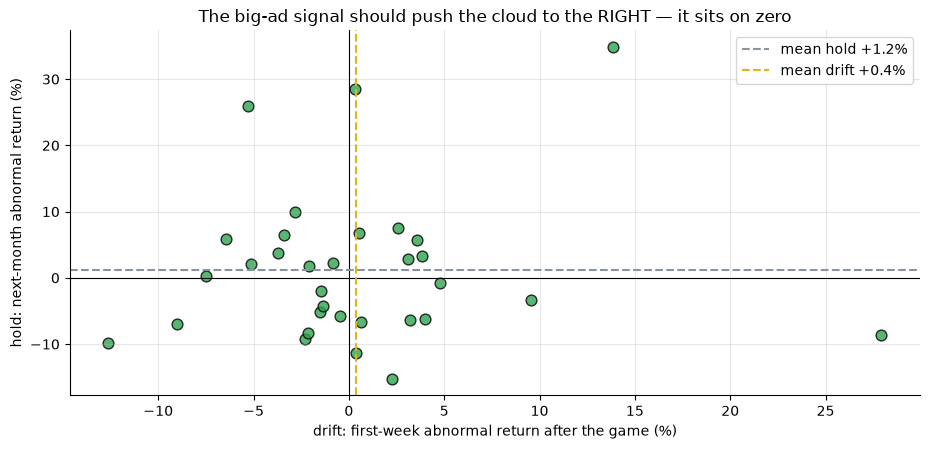

mean drift +0.4%   mean hold +1.2%  (a real signal would be clearly >0)


In [2]:
if HAVE_REAL:
    drifts = EV['drift'].values*100; holds = EV['hold'].values*100; labels = EV['ticker'].values
else:
    rng=np.random.default_rng(720)
    drifts=rng.normal(R['drift'][0],7,R['n_priced']); holds=rng.normal(R['hold'][0],10,R['n_priced'])
    labels=[f'A{i}' for i in range(R['n_priced'])]
fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.scatter(drifts, holds, c=GREEN, s=60, edgecolor='k', alpha=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c='k', lw=.8)
ax.axhline(np.mean(holds), c=GREY, ls='--', label=f'mean hold {np.mean(holds):+.1f}%')
ax.axvline(np.mean(drifts), c=AMBER, ls='--', label=f'mean drift {np.mean(drifts):+.1f}%')
ax.set_xlabel('drift: first-week abnormal return after the game (%)')
ax.set_ylabel('hold: next-month abnormal return (%)')
ax.set_title('The big-ad signal should push the cloud to the RIGHT — it sits on zero')
ax.legend(); plt.tight_layout(); plt.show()
print(f'mean drift {np.mean(drifts):+.1f}%   mean hold {np.mean(holds):+.1f}%  (a real signal would be clearly >0)')

There's the tell. If 'buy the buzz' were true, the dots would sit clearly **to the right** of the zero line (a positive drift). Instead the mean drift is a whisper — **+0.4%** — with the cloud straddling zero. A few big winners (a Coinbase here, a DraftKings there) are cancelled by just as many losers.

**The legs as averages.** Mean abnormal drift and hold, with the win-rate (how often each is positive). A coin is 50%.

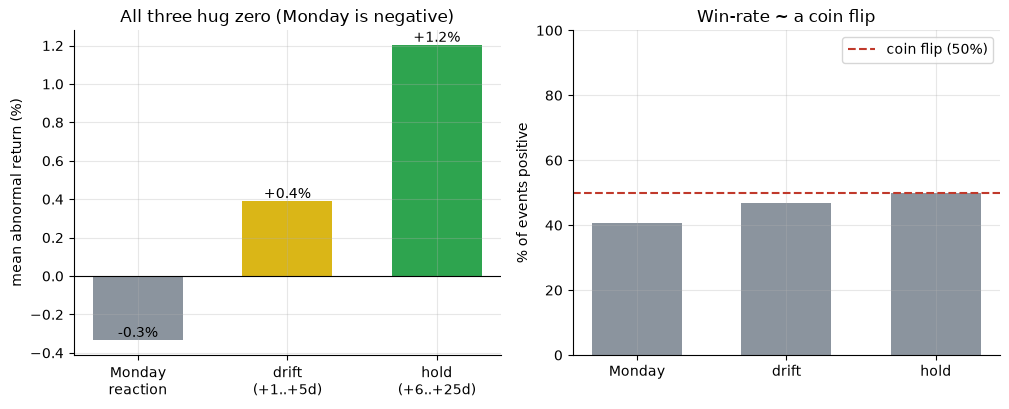

Monday -0.3% (win 41%)   drift +0.4% (win 47%)   hold +1.2% (win 50%)


In [3]:
if HAVE_REAL:
    s = st.summarize(EV, B, placebo=False)
    mm, mw = s['monday']['mean']*100, s['monday']['win']*100
    dm, dw = s['drift']['mean']*100, s['drift']['win']*100
    hm, hw = s['hold']['mean']*100, s['hold']['win']*100
else:
    mm, mw = R['monday'][0], R['monday'][1]
    dm, dw, hm, hw = R['drift'][0], R['drift'][1], R['hold'][0], R['hold'][1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.2, 4.2))
a1.bar(['Monday\nreaction', 'drift\n(+1..+5d)', 'hold\n(+6..+25d)'], [mm, dm, hm],
       color=[GREY, AMBER, GREEN], width=.6)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean abnormal return (%)')
a1.set_title('All three hug zero (Monday is negative)')
for i,v in enumerate([mm,dm,hm]): a1.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
a2.bar(['Monday','drift','hold'], [mw, dw, hw], color=GREY, width=.6)
a2.axhline(50, c=RED, ls='--', label='coin flip (50%)')
a2.set_ylim(0,100); a2.set_ylabel('% of events positive'); a2.set_title('Win-rate ~ a coin flip')
a2.legend(); plt.tight_layout(); plt.show()
print(f'Monday {mm:+.1f}% (win {mw:.0f}%)   drift {dm:+.1f}% (win {dw:.0f}%)   hold {hm:+.1f}% (win {hw:.0f}%)')

The drift is **+0.4%** and positive only **47%** of the time — *below* a coin flip. The Monday reaction is actually **-0.3%** (negative). There's no bump to buy: the ad airs, the world watches, the stock shrugs.

**Could a handful of random weeks look this good?** The honest small-sample test: draw **32** *random* weeks on the same stocks, over and over, and see where the real drift lands against pure luck.

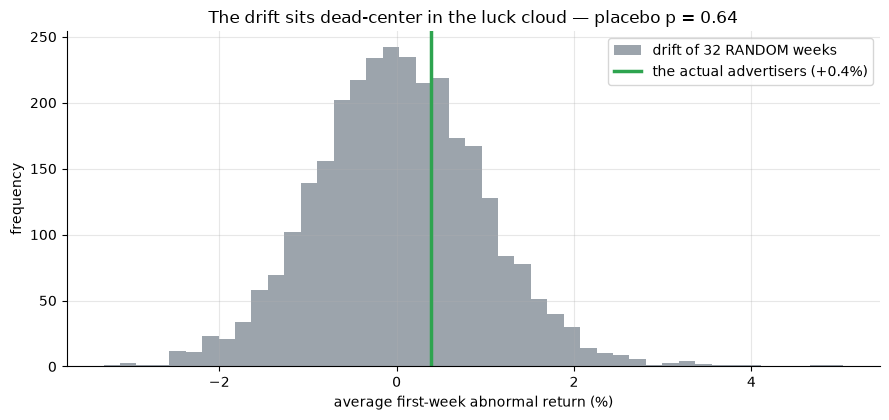

a random 32-week draw matches the drift 64% of the time — not rare at all


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(B, len(EV), leg='drift', observed=EV['drift'].mean(), n_draws=4000)
    obs = pl['obs']*100; pval = pl['p_value']
    tickers=[c for c in B['prices'].columns if c!='SPY']
    exs=[st._excess_log_returns(B['prices'][t], B['prices']['SPY']) for t in tickers]
    exs=[s for s in exs if len(s)>80]; rng=np.random.default_rng(720)
    draws=[]
    for _ in range(3000):
        vals=[]
        for _ in range(len(EV)):
            s=exs[rng.integers(0,len(exs))]; p0=rng.integers(1,len(s)-7); vals.append(np.expm1(s.iloc[p0:p0+5].sum()))
        draws.append(np.mean(vals))
    draws=np.array(draws)*100
else:
    obs=R['drift'][0]; pval=R['drift'][3]; rng=np.random.default_rng(720); draws=rng.normal(0,1.6,3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=45, color=GREY, alpha=.85, label=f'drift of {R["n_priced"]} RANDOM weeks')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'the actual advertisers ({obs:+.1f}%)')
ax.set_xlabel('average first-week abnormal return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The drift sits dead-center in the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random {R["n_priced"]}-week draw matches the drift {pval*100:.0f}% of the time — not rare at all')

The green line — the real advertisers' drift — sits **smack in the middle** of the grey luck cloud (placebo *p* ≈ **0.64**). In plain terms: **three-dozen random weeks would look about this 'special' by chance.** The drift isn't attention; it's noise with a famous paper and a sock puppet attached.

## 5 · The verdict

- **Signal — None.** The drift is **+0.4%** on a *below*-coin-flip win-rate, the day-one reaction is **-0.3%** (negative), and the drift sits dead-center in the luck cloud. The 2005 paper found it on a 2000–04 sample; this modern tape doesn't.
- **Tradability — Mirage.** Buying the ad basket earns **+0.4% gross** over five days — noise, and it's just large-cap beta. Nothing to size.
- **"Big-ad signal"? — Not supported.** We remember Pets.com and the sock puppet *because* they were extreme — and they **went bust**, so they never enter a fair sample. On the survivors, the buzz doesn't move the tape.

## 6 · Could you actually trade it? — a basket that earns nothing

Forget significance and just price the believers' trade: **buy every advertiser Monday, sell a week later.** Here's what that basket makes per event, gross and net of the (modest, large-cap) costs of getting in and out.

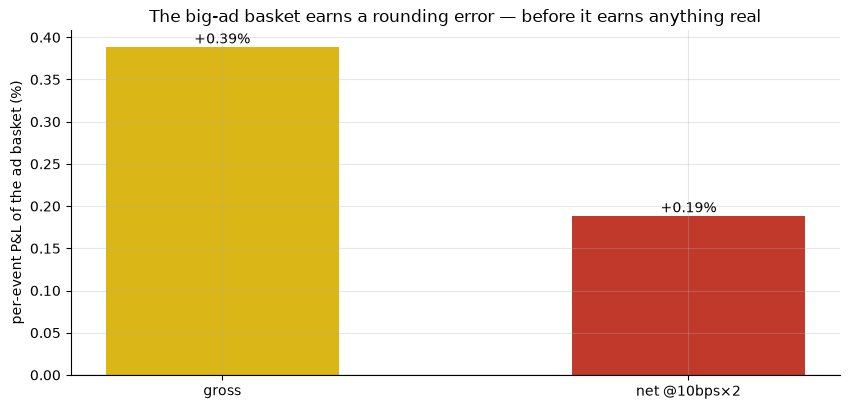

ad basket: +0.39% gross, +0.19% net over 5 days — a coin-flip rounding error


In [5]:
if HAVE_REAL:
    c = st.net_of_costs(EV, cost_bps=10.0)
    gd, nd = c['gross_drift']*100, c['net_drift']*100
else:
    gd, nd = R['cost']['gross_drift'], R['cost']['net_drift']
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.bar(['gross', 'net @10bps×2'], [gd, nd], color=[AMBER, RED], width=.5)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('per-event P&L of the ad basket (%)')
ax.set_title('The big-ad basket earns a rounding error — before it earns anything real')
for i,v in enumerate([gd,nd]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'ad basket: {gd:+.2f}% gross, {nd:+.2f}% net over 5 days — a coin-flip rounding error')

The basket is **+0.4% gross** and **+0.2% net** over five days — a rounding error on a coin-flip win-rate. Whatever tiny positive you see is well inside its own error bar and is indistinguishable from just holding a few large caps for a week in February. There's no machine here — just $7-million commercials and a memorable sock puppet.

## 7 · Going further 🚪

- **The other attention effects.** [Study 389 — Name-Change-Effect](../389-name-change-effect/) asks whether renaming toward the hot theme (`.com`, `Blockchain`, `AI`) pays — same family (a label / an attention grab, not a fundamental), same verdict.
- **The anecdote trap.** [Study 343 — Data-Mining-Roulette](../343-data-mining-roulette/) shows how a few loud cases manufacture a 'law' that vanishes on a representative sample.
- **Add the corpses.** Our survivor tape is biased *for* the story; get the delisted advertisers (Pets.com, Computer.com, Kozmo.com) and the drift wouldn't improve — those names went to **−100%**, which is a bankruptcy, not a tradable 'buzz'.

*Think the big-ad signal is real and harvestable? Capture the events, draw the same number of random weeks, and show the drift landing **outside** the cloud **and** a Monday reaction that's reliably positive — then we'll talk.*